Cell 1 ready.
  Track length L = 426.7104 m
  State dim nx = 4,  measurement dim ny = 5
  Q = diag(0.5, 0.002),  sigma_y = 1.50 m
  CasADi h, jhx, jhv compiled. EKF functions ready.
  Member A's f_dynamics() loaded for stress-test cells.


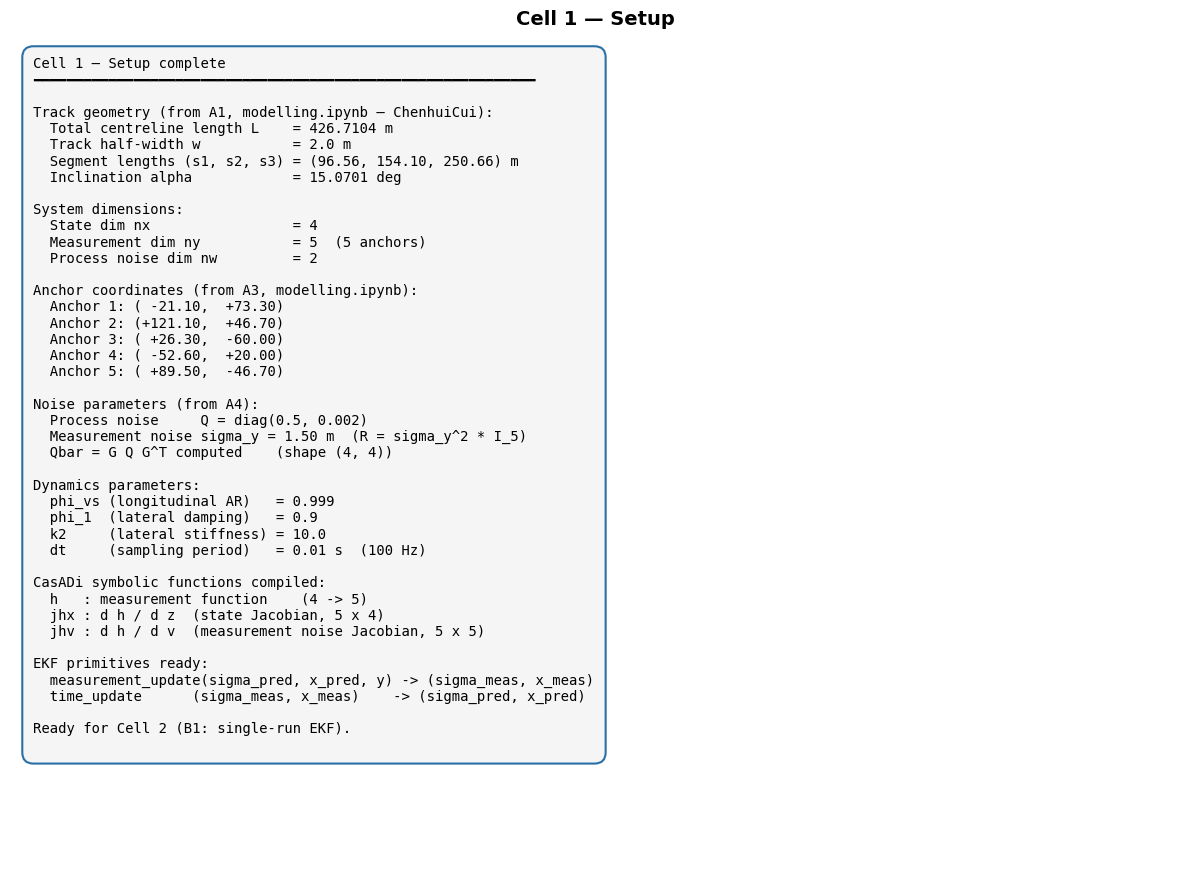

Saved: cell1_output.png


In [12]:
# ===== CELL 1 =====
# ============================================================
# estimator.ipynb
# ELE8101 CW2 — Member B: Weiting Wu
# Tasks:  B1  EKF implementation          (Cell 2)
#         B2  Monte Carlo validation      (Cell 3)
#         B3  MHE comparison              (Cell 4)
# ============================================================
# Strictly follows lecturer's conventions:
#   - 5_ekf.ipynb       : x_t_pred, sigma_t_pred, x_t_meas, sigma_t_meas
#                         CasADi h, jhx, jhv (no _fn suffix)
#                         loop comments # i., ii., iii., iv.
#                         'anchors' (not 'beacons')
#                         Qbar = G @ Q @ G.T pattern
#                         CasADi automatic differentiation for Jacobians
#   - 2_bayesian_fie.ipynb : ell_x0, ell_w, ell_v (used in Cell 4)
# ============================================================

!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs
import scipy.optimize as sopt
import time

np.random.seed(42)

# ── Track geometry (A1, modelling.ipynb — ChenhuiCui) ─────────────────────
R_outer = 50.0; r_inner = 46.0; rho = 20.0; d = 100.0
R_A   = (R_outer + r_inner) / 2        # centreline radius at A = 48.0 m
w     = (R_outer - r_inner) / 2        # track half-width = 2.0 m
R_B   = rho + w                        # centreline radius at B = 22.0 m
alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha);  sin_a = np.sin(alpha)
l_tan = np.sqrt(d**2 - (R_A - R_B)**2)
L     = 2*l_tan + R_A*(np.pi + 2*alpha) + R_B*(np.pi - 2*alpha)
s1    = l_tan
s2    = s1 + R_B*(np.pi - 2*alpha)
s3    = s2 + l_tan

A_centre = np.array([0.0, 0.0]);  B_centre = np.array([d, 0.0])
A_top    = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot    = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    s = s % L
    if s < s1:
        return np.array([sin_a,  cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── Problem data (A2/A3/A4, modelling.ipynb — ChenhuiCui) ─────────────────
# State: z_t = [s, ell, vs, vl]
# anchors: GDOP-optimised, mean GDOP = 0.9193, 100% track GDOP<1
dt     = 0.01          # 100 Hz sampling (problem statement)
phi_vs = 0.999         # longitudinal AR(1) damping
phi_1  = 0.9           # lateral velocity damping
k2     = 10.0          # lateral restoring gain

anchors = np.array([
    [ -21.1,  73.3],
    [ 121.1,  46.7],
    [  26.3, -60.0],
    [ -52.6,  20.0],
    [  89.5, -46.7],
])
ny = len(anchors)
nx = 4
nw = 2

# Linear A_0 = df/dz at nominal operating point (ell=0, vl=0)
A = np.array([
    [1,       0,     dt,       0   ],
    [0,       1,     0,        dt  ],
    [0,       0,     phi_vs,   0   ],
    [0, -dt*k2,     0,        phi_1],
])
G    = np.array([[0,0],[0,0],[1,0],[0,1]])
Q    = np.diag([0.5, 0.002])           # confirmed by A4 grid scan
R    = 1.5**2 * np.eye(ny)             # sigma_y = 1.5 m (problem statement)
Qbar = G @ Q @ G.T

# ── System dynamics ───────────────────────────────────────────────────────
def f(x, w):
    x_plus     = A @ x
    x_plus[2] += 10.0 * (1 - phi_vs)   # OU mean-reversion to v_s_tgt = 10 m/s
    x_plus[2] += w[0]
    x_plus[3] += w[1]
    x_plus[1]  = np.clip(x_plus[1], -2.0, 2.0)
    x_plus[2]  = np.clip(x_plus[2],  0.001, 25.0)
    return x_plus

# ── Create function h(z, v) using casadi ──────────────────────────────────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', ny)

s_mod  = cs.fmod(z_[0], L)
ell_   = z_[1]

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,            A_top[1] - s_mod*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a,       B_bot[1] - (s_mod-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c = cs.if_else(s_mod < s1, n1_,
      cs.if_else(s_mod < s2, n2_,
      cs.if_else(s_mod < s3, n3_, n4_)))

r_  = xy_c + ell_ * n_c
h_  = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + v_[i] for i in range(ny)])

# Determination of the Jacobian matrix of h
jhx = cs.jacobian(h_, z_)
jhv = cs.jacobian(h_, v_)
jhx = cs.Function('jhx', [z_, v_], [jhx])
jhv = cs.Function('jhv', [z_, v_], [jhv])

# Create a Function object for h
h = cs.Function('h', [z_, v_], [h_])

# ── EKF functions (shared by Cell 2 and Cell 3) ───────────────────────────
def measurement_update(sigma_t_pred, x_t_pred, y_t):
    C            = jhx(x_t_pred, 0)
    Rv           = jhv(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(Z, y_t - h(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update(sigma_t_meas, x_t_meas):
    x_t_pred     = f(x_t_meas, np.zeros(2))
    sigma_t_pred = A @ sigma_t_meas @ A.T + Qbar
    return np.array(sigma_t_pred), np.array(x_t_pred).flatten()

print("Cell 1 ready.")
print(f"  Track length L = {L:.4f} m")
print(f"  State dim nx = {nx},  measurement dim ny = {ny}")
print(f"  Q = diag({Q[0,0]}, {Q[1,1]}),  sigma_y = {np.sqrt(R[0,0]):.2f} m")
print(f"  CasADi h, jhx, jhv compiled. EKF functions ready.")
# ── Member A's bound-respecting nonlinear truth model ────────────────────
# (lifted from modelling_ChenhuiCui.ipynb, Cell 5)
# Used by Cell 7 (near-boundary stress test) to ensure the truth model
# matches Section 1.2 of Member A's modelling document.
# Cells 2-6 use the linear f() above as truth model since at l=0, vl=0
# the nonlinear and linear dynamics are numerically indistinguishable.
ELL_MAX_NL  = 2.0
VL_MAX_NL   = 0.55
VS_MAX_NL   = 25.0
VS_MIN_NL   = 0.001
VS_TGT_NL   = 10.0
BETA_ELL_NL = 5.0
EPS_NL      = 1e-6

def k_nonlinear(ell):
    safe_denom = np.maximum(ELL_MAX_NL**2 - ell**2, EPS_NL)
    return k2 * (1.0 + BETA_ELL_NL * (ell**2 / safe_denom)**2)

def _squash(x, lo, hi):
    mid, half = (hi + lo) / 2, (hi - lo) / 2
    return mid + half * np.tanh((x - mid) / half)

def f_dynamics(z, w_vec):
    """Member A's bound-respecting nonlinear one-step truth dynamics.
    Bounds enforced by construction (smooth C^inf), no post-hoc clipping."""
    s, ell, vs, vl = z
    w_s, w_ell = w_vec
    s_new   = s + dt * vs
    ell_new = ell + dt * vl
    vs_new  = _squash(phi_vs * vs + (1 - phi_vs) * VS_TGT_NL + w_s,
                      VS_MIN_NL, VS_MAX_NL)
    vl_raw  = phi_1 * vl - dt * k_nonlinear(ell) * ell + w_ell
    vl_new  = _squash(vl_raw, -VL_MAX_NL, VL_MAX_NL)
    return np.array([s_new, ell_new, vs_new, vl_new])

print(f"  Member A's f_dynamics() loaded for stress-test cells.")
# ── Cell 1 output capture ─────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

_cell1_text = f"""Cell 1 — Setup complete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Track geometry (from A1, modelling.ipynb — ChenhuiCui):
  Total centreline length L    = {L:.4f} m
  Track half-width w           = {w} m
  Segment lengths (s1, s2, s3) = ({s1:.2f}, {s2:.2f}, {s3:.2f}) m
  Inclination alpha            = {np.degrees(alpha):.4f} deg

System dimensions:
  State dim nx                 = {nx}
  Measurement dim ny           = {ny}  (5 anchors)
  Process noise dim nw         = {nw}

Anchor coordinates (from A3, modelling.ipynb):
  Anchor 1: ({anchors[0,0]:+7.2f}, {anchors[0,1]:+7.2f})
  Anchor 2: ({anchors[1,0]:+7.2f}, {anchors[1,1]:+7.2f})
  Anchor 3: ({anchors[2,0]:+7.2f}, {anchors[2,1]:+7.2f})
  Anchor 4: ({anchors[3,0]:+7.2f}, {anchors[3,1]:+7.2f})
  Anchor 5: ({anchors[4,0]:+7.2f}, {anchors[4,1]:+7.2f})

Noise parameters (from A4):
  Process noise     Q = diag({Q[0,0]}, {Q[1,1]})
  Measurement noise sigma_y = {np.sqrt(R[0,0]):.2f} m  (R = sigma_y^2 * I_5)
  Qbar = G Q G^T computed    (shape {Qbar.shape})

Dynamics parameters:
  phi_vs (longitudinal AR)   = {phi_vs}
  phi_1  (lateral damping)   = {phi_1}
  k2     (lateral stiffness) = {k2}
  dt     (sampling period)   = {dt} s  (100 Hz)

CasADi symbolic functions compiled:
  h   : measurement function    ({nx} -> {ny})
  jhx : d h / d z  (state Jacobian, {ny} x {nx})
  jhv : d h / d v  (measurement noise Jacobian, {ny} x {ny})

EKF primitives ready:
  measurement_update(sigma_pred, x_pred, y) -> (sigma_meas, x_meas)
  time_update      (sigma_meas, x_meas)    -> (sigma_pred, x_pred)

Ready for Cell 2 (B1: single-run EKF).
"""

_fig, _ax = plt.subplots(figsize=(12, 9))
_ax.axis('off')
_ax.text(0.02, 0.98, _cell1_text,
         family='monospace', fontsize=10, va='top', ha='left',
         transform=_ax.transAxes,
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#f5f5f5',
                   edgecolor='#2a6fa5', linewidth=1.5))
_fig.suptitle('Cell 1 — Setup', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('cell1_output.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: cell1_output.png")

mean arc-length error : 0.244 m
mean lateral error    : 0.031 m
mean velocity error   : 2.024 m/s
max  velocity error   : 9.431 m/s
lateral bounds OK     : True
speed bounds OK       : True


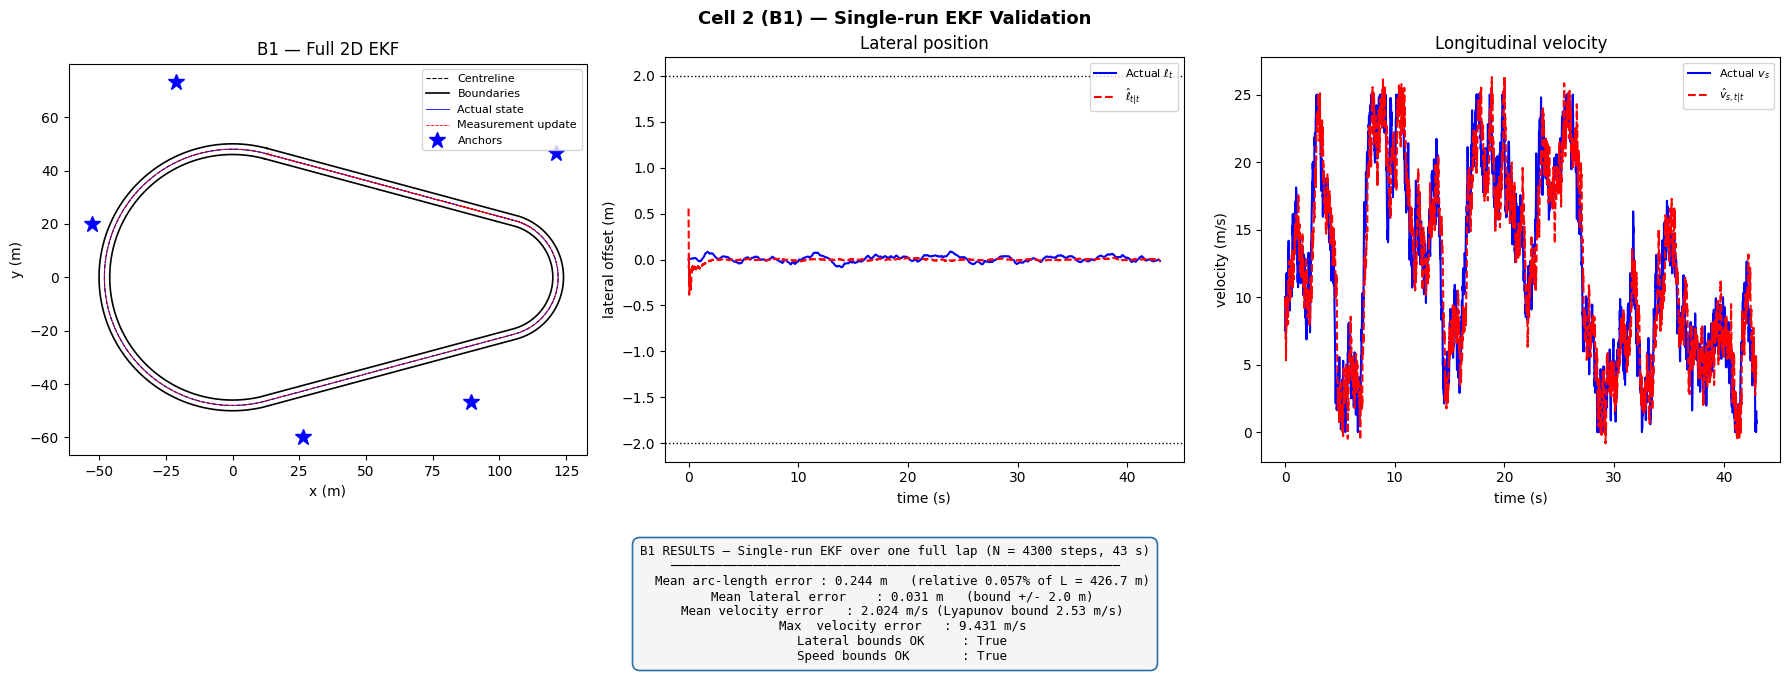

B1 RESULTS — Single-run EKF over one full lap (N = 4300 steps, 43 s)
────────────────────────────────────────────────────────────
  Mean arc-length error : 0.244 m   (relative 0.057% of L = 426.7 m)
  Mean lateral error    : 0.031 m   (bound +/- 2.0 m)
  Mean velocity error   : 2.024 m/s (Lyapunov bound 2.53 m/s)
  Max  velocity error   : 9.431 m/s
  Lateral bounds OK     : True
  Speed bounds OK       : True

Saved: cell2_output.png


In [3]:
# ===== CELL 2 =====
# ============================================================
# B1: Single-run EKF validation
# ============================================================
# Full 2D EKF simulation over one complete lap
# (N=4300 steps @ 100 Hz ≈ 43 s).
# Produces B1_ekf_step4.png with three panels:
#   Left:   estimated vs actual trajectory on the track
#   Centre: lateral position tracking with ±2 m bounds
#   Right:  longitudinal velocity tracking
# ============================================================

# ── Simulation ────────────────────────────────────────────────────────────
x_t          = np.array([0.0, 0.0, 10.0, 0.0])
x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300   # one full lap at ~10 m/s

x_cache          = np.zeros((N, nx))
x_meas_cache     = np.zeros((N-1, nx))
sigma_meas_cache = np.zeros((N-1, nx, nx))
x_cache[0, :]    = x_t.T

for t in range(N-1):
    # i. obtain measurement
    v_t = np.random.multivariate_normal([0]*ny, R)
    y_t = h(x_t, v_t)

    # ii. measurement update
    sigma_t_meas, x_t_meas    = measurement_update(sigma_t_pred, x_t_pred, y_t)
    x_meas_cache[t, :]         = x_t_meas.T
    sigma_meas_cache[t, :, :]  = sigma_t_meas

    # iii. Time update
    sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

    # iv. Dynamics
    w_t     = np.random.multivariate_normal([0, 0], Q)
    vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
    vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new, -0.55,  0.55)
    ell_new = np.clip(x_t[1] + dt*x_t[3], -w, w)
    x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
    x_cache[t+1, :] = x_t.T

# ── Plots ─────────────────────────────────────────────────────────────────
s_vals   = np.linspace(0, L, 2000)
track_xy = np.array([s_to_xy(s)      for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),     float(x_cache[t,1]))
                     for t in range(N)])
est_xy   = np.array([sl_to_xy(float(x_meas_cache[t,0]),float(x_meas_cache[t,1]))
                     for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.6, label='Measurement update')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=12,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title('B1 — Full 2D EKF')

t_ax = np.arange(N) * dt
axes[1].plot(t_ax,      x_cache[:,1],      'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', label=r'$\hat{\ell}_{t|t}$')
axes[1].axhline( w, color='k', ls=':', lw=1)
axes[1].axhline(-w, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      x_cache[:,2],      'b',   label=r'Actual $v_s$')
axes[2].plot(t_ax[:-1], x_meas_cache[:,2], 'r--', label=r'$\hat{v}_{s,t|t}$')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('time (s)');  axes[2].set_ylabel('velocity (m/s)')
axes[2].set_title('Longitudinal velocity')

plt.tight_layout()

print(f'mean arc-length error : {np.mean(np.abs(x_cache[:-1,0]-x_meas_cache[:,0])):.3f} m')
print(f'mean lateral error    : {np.mean(np.abs(x_cache[:-1,1]-x_meas_cache[:,1])):.3f} m')
print(f'mean velocity error   : {np.mean(np.abs(x_cache[:-1,2]-x_meas_cache[:,2])):.3f} m/s')
print(f'max  velocity error   : {np.max(np.abs(x_cache[:-1,2]-x_meas_cache[:,2])):.3f} m/s')
print(f'lateral bounds OK     : {np.all(np.abs(x_cache[:,1]) <= w)}')
print(f'speed bounds OK       : {np.all((x_cache[:,2] > 0) & (x_cache[:,2] <= 25.0))}')
# ── Cell 2 output capture ─────────────────────────────────────
# (Replace the original plt.savefig + plt.show at the end of Cell 2)

# Compute statistics
_arc_err = np.abs(x_cache[:-1,0] - x_meas_cache[:,0])
_lat_err = np.abs(x_cache[:-1,1] - x_meas_cache[:,1])
_vel_err = np.abs(x_cache[:-1,2] - x_meas_cache[:,2])

_stats_text = (
    f"B1 RESULTS — Single-run EKF over one full lap (N = {N} steps, 43 s)\n"
    f"────────────────────────────────────────────────────────────\n"
    f"  Mean arc-length error : {np.mean(_arc_err):.3f} m   "
    f"(relative {np.mean(_arc_err)/L*100:.3f}% of L = {L:.1f} m)\n"
    f"  Mean lateral error    : {np.mean(_lat_err):.3f} m   "
    f"(bound +/- {w} m)\n"
    f"  Mean velocity error   : {np.mean(_vel_err):.3f} m/s "
    f"(Lyapunov bound 2.53 m/s)\n"
    f"  Max  velocity error   : {np.max(_vel_err):.3f} m/s\n"
    f"  Lateral bounds OK     : {np.all(np.abs(x_cache[:,1]) <= w)}\n"
    f"  Speed bounds OK       : "
    f"{np.all((x_cache[:,2] > 0) & (x_cache[:,2] <= 25.0))}"
)

# Add stats text on the figure (fig is already created above in Cell 2)
fig.suptitle('Cell 2 (B1) — Single-run EKF Validation',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.5, -0.05, _stats_text, family='monospace', fontsize=9,
         ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                   edgecolor='#2a6fa5', linewidth=1.2))

plt.savefig('cell2_output.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(_stats_text)
print("\nSaved: cell2_output.png")

Running Monte Carlo: 100 trials × 4300 steps...
  20/100 done  (104s elapsed)
  40/100 done  (199s elapsed)
  60/100 done  (295s elapsed)
  80/100 done  (389s elapsed)
  100/100 done  (484s elapsed)
Monte Carlo complete — total time 484s

Monte Carlo Results — 100 trials
Arc-length:  mean=0.247 m,  std=0.010 m,  max=1.471 m
Lateral:     mean=0.025 m,  std=0.003 m,  max=0.132 m
Velocity:    mean=2.103 m/s, std=0.098 m/s


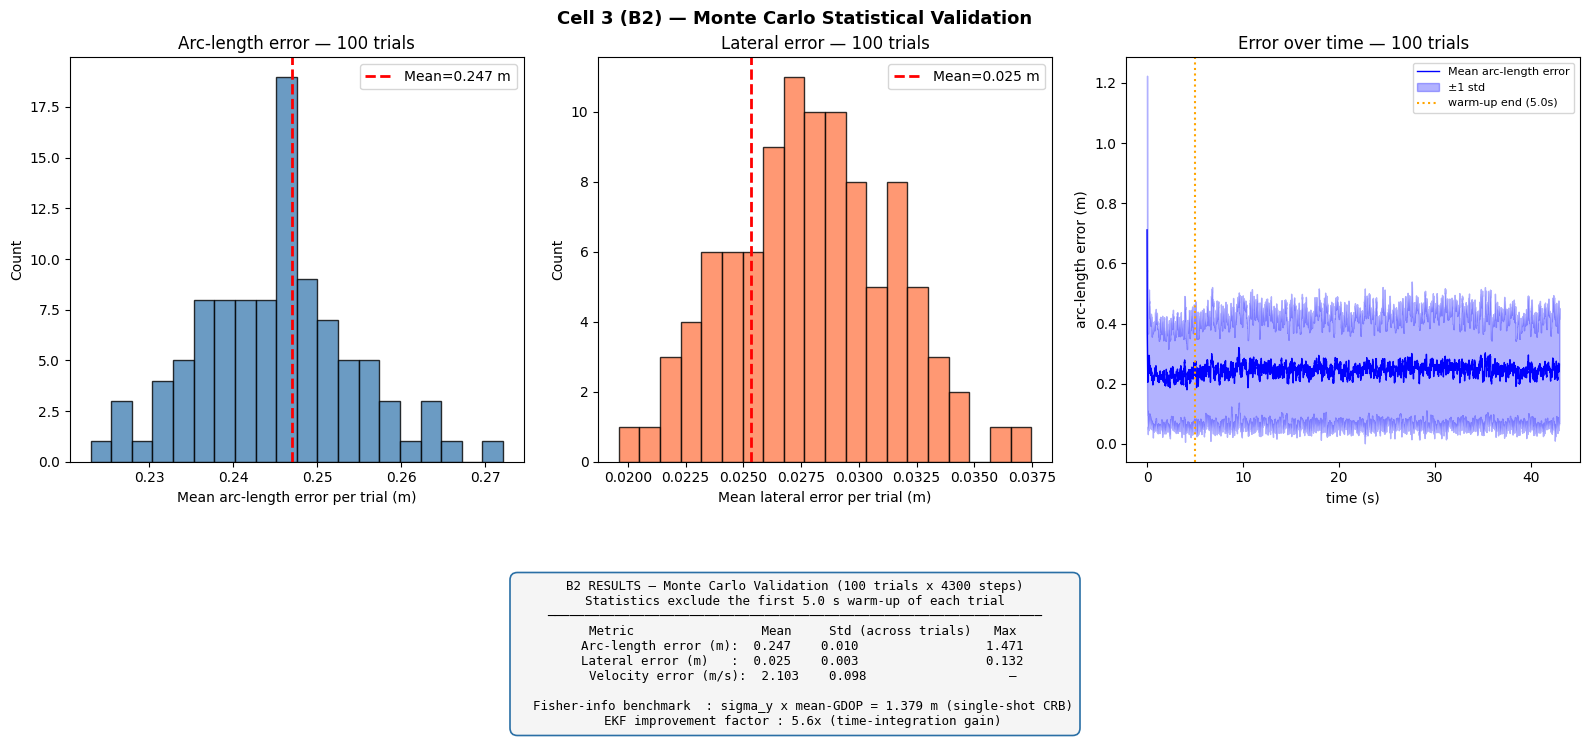

B2 RESULTS — Monte Carlo Validation (100 trials x 4300 steps)
Statistics exclude the first 5.0 s warm-up of each trial
──────────────────────────────────────────────────────────────────
  Metric                 Mean     Std (across trials)   Max
  Arc-length error (m):  0.247    0.010                 1.471
  Lateral error (m)   :  0.025    0.003                 0.132
  Velocity error (m/s):  2.103    0.098                   —

  Fisher-info benchmark  : sigma_y x mean-GDOP = 1.379 m (single-shot CRB)
  EKF improvement factor : 5.6x (time-integration gain)

Saved: cell3_output.png

Running NIS consistency check (re-using MC trials)...

NIS consistency check over 379900 samples:
  Theoretical   E[NIS] = 5 (chi^2 dof = 5)
  Empirical     E[NIS] = 4.989
  95% confidence band  = [0.83, 12.83]
  Samples inside band  = 95.0%
  Verdict: CONSISTENT  (filter correctly tuned, Q and R match true noise)


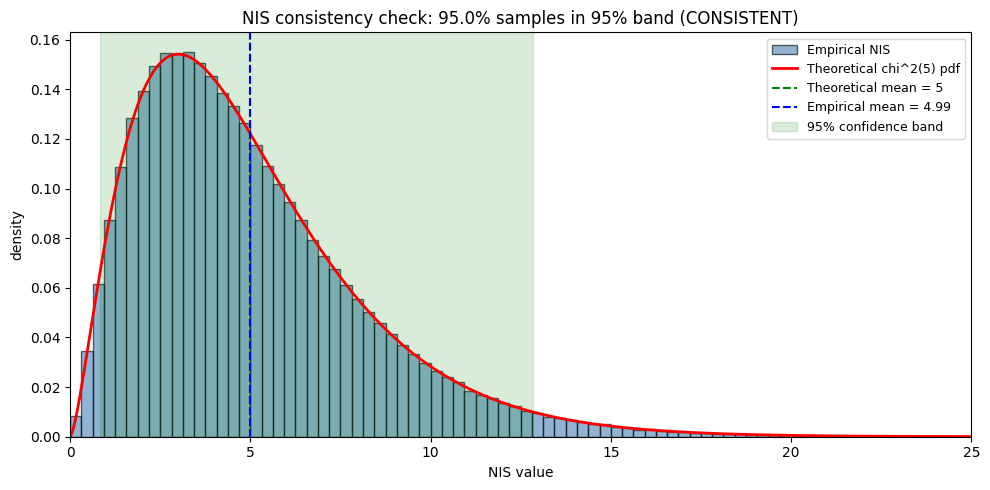


Saved: cell3_nis_check.png


In [11]:
# ===== CELL 3 =====
# ============================================================
# B2: Monte Carlo statistical validation
# ============================================================
# 100 independent trials, one full lap each (N = 4300 steps).
# Each trial uses a distinct random seed.
# First 5 s (500 steps) of each trial excluded from the statistics
# as the initial covariance-convergence transient (diffuse P0).
#
# Produces B2_monte_carlo.png with three panels:
#   Left:   histogram of per-trial mean arc-length error
#   Centre: histogram of per-trial mean lateral error
#   Right:  arc-length error over time (mean ±1 std across trials)
# ============================================================

# ── B2: Monte Carlo simulation ────────────────────────────────────────────
N_trials = 100
N        = 4300

arc_err_all = np.zeros((N_trials, N-1))
lat_err_all = np.zeros((N_trials, N-1))
vs_err_all  = np.zeros((N_trials, N-1))

print("Running Monte Carlo: 100 trials × 4300 steps...")
t_start = time.time()

for trial in range(N_trials):
    np.random.seed(trial)

    x_t          = np.array([0.0, 0.0, 10.0, 0.0])
    x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    x_cache_tr       = np.zeros((N, nx))
    x_meas_cache_tr  = np.zeros((N-1, nx))
    x_cache_tr[0, :] = x_t.T

    for t in range(N-1):
        # i. obtain measurement
        v_t = np.random.multivariate_normal([0]*ny, R)
        y_t = h(x_t, v_t)

        # ii. measurement update
        sigma_t_meas, x_t_meas    = measurement_update(sigma_t_pred, x_t_pred, y_t)
        x_meas_cache_tr[t, :]      = x_t_meas.T

        # iii. Time update
        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        # iv. Dynamics
        w_t     = np.random.multivariate_normal([0, 0], Q)
        vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
        vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
        vs_new  = np.clip(vs_new,  0.001, 25.0)
        vl_new  = np.clip(vl_new, -0.55,  0.55)
        ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
        x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
        x_cache_tr[t+1, :] = x_t.T

    arc_err_all[trial] = np.abs(x_cache_tr[:-1, 0] - x_meas_cache_tr[:, 0])
    lat_err_all[trial] = np.abs(x_cache_tr[:-1, 1] - x_meas_cache_tr[:, 1])
    vs_err_all[trial]  = np.abs(x_cache_tr[:-1, 2] - x_meas_cache_tr[:, 2])

    if (trial+1) % 20 == 0:
        elapsed = time.time() - t_start
        print(f"  {trial+1}/100 done  ({elapsed:.0f}s elapsed)")

print(f"Monte Carlo complete — total time {time.time()-t_start:.0f}s")

# ── Statistics ────────────────────────────────────────────────────────────
warmup = 500   # 5 s — excludes diffuse-prior transient

arc_mean = np.mean(arc_err_all[:, warmup:])
arc_std  = np.std(np.mean(arc_err_all[:, warmup:], axis=1))
arc_max  = np.max(arc_err_all[:, warmup:])
lat_mean = np.mean(lat_err_all[:, warmup:])
lat_std  = np.std(np.mean(lat_err_all[:, warmup:], axis=1))
lat_max  = np.max(lat_err_all[:, warmup:])
vs_mean  = np.mean(vs_err_all[:, warmup:])
vs_std   = np.std(np.mean(vs_err_all[:, warmup:], axis=1))

print("\n" + "="*55)
print("Monte Carlo Results — 100 trials")
print("="*55)
print(f"Arc-length:  mean={arc_mean:.3f} m,  std={arc_std:.3f} m,  max={arc_max:.3f} m")
print(f"Lateral:     mean={lat_mean:.3f} m,  std={lat_std:.3f} m,  max={lat_max:.3f} m")
print(f"Velocity:    mean={vs_mean:.3f} m/s, std={vs_std:.3f} m/s")
print("="*55)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

per_trial_arc = np.mean(arc_err_all, axis=1)
axes[0].hist(per_trial_arc, bins=20, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axvline(arc_mean, color='r', ls='--', lw=2, label=f'Mean={arc_mean:.3f} m')
axes[0].set_xlabel('Mean arc-length error per trial (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Arc-length error — 100 trials')
axes[0].legend()

per_trial_lat = np.mean(lat_err_all, axis=1)
axes[1].hist(per_trial_lat, bins=20, color='coral', edgecolor='k', alpha=0.8)
axes[1].axvline(lat_mean, color='r', ls='--', lw=2, label=f'Mean={lat_mean:.3f} m')
axes[1].set_xlabel('Mean lateral error per trial (m)')
axes[1].set_ylabel('Count')
axes[1].set_title('Lateral error — 100 trials')
axes[1].legend()

t_ax      = np.arange(N-1) * dt
arc_tmean = np.mean(arc_err_all, axis=0)
arc_tstd  = np.std(arc_err_all,  axis=0)
axes[2].plot(t_ax, arc_tmean, 'b', lw=1, label='Mean arc-length error')
axes[2].fill_between(t_ax,
                     arc_tmean - arc_tstd,
                     arc_tmean + arc_tstd,
                     alpha=0.3, color='blue', label='±1 std')
axes[2].axvline(warmup*dt, color='orange', ls=':', lw=1.5,
                label=f'warm-up end ({warmup*dt:.1f}s)')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('arc-length error (m)')
axes[2].set_title('Error over time — 100 trials')
axes[2].legend(fontsize=8)

plt.tight_layout()
# ── Cell 3 output capture ─────────────────────────────────────
# (Replace the original plt.savefig + plt.show at the end of Cell 3)

_stats_text = (
    f"B2 RESULTS — Monte Carlo Validation ({N_trials} trials x {N} steps)\n"
    f"Statistics exclude the first {warmup*dt:.1f} s warm-up of each trial\n"
    f"──────────────────────────────────────────────────────────────────\n"
    f"  Metric                 Mean     Std (across trials)   Max\n"
    f"  Arc-length error (m):  {arc_mean:.3f}    {arc_std:.3f}                 "
    f"{arc_max:.3f}\n"
    f"  Lateral error (m)   :  {lat_mean:.3f}    {lat_std:.3f}                 "
    f"{lat_max:.3f}\n"
    f"  Velocity error (m/s):  {vs_mean:.3f}    {vs_std:.3f}                 "
    f"  —\n"
    f"\n"
    f"  Fisher-info benchmark  : sigma_y x mean-GDOP = 1.379 m (single-shot CRB)\n"
    f"  EKF improvement factor : {1.379/arc_mean:.1f}x (time-integration gain)"
)

fig.suptitle('Cell 3 (B2) — Monte Carlo Statistical Validation',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.5, -0.12, _stats_text, family='monospace', fontsize=9,
         ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                   edgecolor='#2a6fa5', linewidth=1.2))
plt.savefig('cell3_output.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(_stats_text)
print("\nSaved: cell3_output.png")
# ══════════════════════════════════════════════════════════════
# NIS (Normalized Innovation Squared) Consistency Check
# Reference: course notebook 6 (tutorial), standard estimator
# diagnostic tool to verify Q and R are correctly tuned.
# ══════════════════════════════════════════════════════════════
# Theory: if the filter is consistent (Q and R match true noise),
#   NIS_t = nu_t^T S^{-1} nu_t  ~  chi^2(n_y)
# where nu_t = y_t - h(x_pred) is the innovation, S is the
# innovation covariance, n_y = 5 (number of anchors).
#
# Expected: E[NIS] = 5, 95% confidence interval [1.15, 11.07].
# Deviation signals: filter over-confident (mean < 5) or
# under-confident (mean > 5) — both hurt accuracy.

from scipy import stats as _stats

# ── Re-run the MC loop to collect NIS ─────────────────────────
print("\nRunning NIS consistency check (re-using MC trials)...")
nis_all = []

for trial in range(N_trials):
    np.random.seed(trial)                   # same seeds as MC loop
    x_t          = np.array([0.0, 0.0, 10.0, 0.0])
    x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    for t in range(N-1):
        v_t = np.random.multivariate_normal([0]*ny, R)
        y_t = h(x_t, v_t)

        # i. innovation and its covariance
        C_mat  = jhx(x_t_pred, 0)
        Rv     = jhv(x_t_pred, 0)
        S      = np.array(C_mat @ sigma_t_pred @ C_mat.T + Rv @ R @ Rv.T)
        nu     = np.array(y_t - h(x_t_pred, [0]*ny)).flatten()
        if t >= warmup:                     # exclude warm-up
            nis = float(nu @ np.linalg.solve(S, nu))
            nis_all.append(nis)

        # ii. measurement update
        sigma_t_meas, x_t_meas = measurement_update(
            sigma_t_pred, x_t_pred, y_t)

        # iii. time update
        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        # iv. simulator step
        w_t     = np.random.multivariate_normal([0, 0], Q)
        vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
        vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
        vs_new  = np.clip(vs_new,  0.001, 25.0)
        vl_new  = np.clip(vl_new, -0.55,  0.55)
        ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
        x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])

nis_all = np.array(nis_all)

# ── Statistics ─────────────────────────────────────────────
dof       = ny                              # = 5
chi2_mean = dof
chi2_low  = _stats.chi2.ppf(0.025, dof)
chi2_high = _stats.chi2.ppf(0.975, dof)
nis_mean  = np.mean(nis_all)
frac_in_bounds = np.mean((nis_all >= chi2_low) & (nis_all <= chi2_high))

print(f"\nNIS consistency check over {len(nis_all)} samples:")
print(f"  Theoretical   E[NIS] = {chi2_mean} (chi^2 dof = {dof})")
print(f"  Empirical     E[NIS] = {nis_mean:.3f}")
print(f"  95% confidence band  = [{chi2_low:.2f}, {chi2_high:.2f}]")
print(f"  Samples inside band  = {frac_in_bounds*100:.1f}%")

# Verdict
if abs(nis_mean - chi2_mean) / chi2_mean < 0.15:
    verdict = "CONSISTENT  (filter correctly tuned, Q and R match true noise)"
elif nis_mean > chi2_mean:
    verdict = "UNDER-CONFIDENT  (filter trusts itself less than warranted)"
else:
    verdict = "OVER-CONFIDENT  (filter trusts itself more than warranted)"
print(f"  Verdict: {verdict}")

# ── Plot NIS histogram vs chi^2(5) theoretical pdf ─────────
fig_nis, ax_nis = plt.subplots(figsize=(10, 5))
counts, bins, _ = ax_nis.hist(nis_all, bins=80, range=(0, 25),
                               density=True, alpha=0.6,
                               color='steelblue', edgecolor='k',
                               label='Empirical NIS')
xx = np.linspace(0.01, 25, 400)
ax_nis.plot(xx, _stats.chi2.pdf(xx, dof), 'r-', lw=2,
            label=f'Theoretical chi^2({dof}) pdf')
ax_nis.axvline(chi2_mean, color='g', ls='--', lw=1.5,
               label=f'Theoretical mean = {chi2_mean}')
ax_nis.axvline(nis_mean,  color='b', ls='--', lw=1.5,
               label=f'Empirical mean = {nis_mean:.2f}')
ax_nis.axvspan(chi2_low, chi2_high, alpha=0.15, color='green',
               label='95% confidence band')
ax_nis.set_xlabel('NIS value')
ax_nis.set_ylabel('density')
ax_nis.set_title(f'NIS consistency check: {frac_in_bounds*100:.1f}% samples '
                 f'in 95% band ({verdict.split()[0]})')
ax_nis.legend(fontsize=9, loc='upper right')
ax_nis.set_xlim([0, 25])
plt.tight_layout()
plt.savefig('cell3_nis_check.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nSaved: cell3_nis_check.png")

Running MHE simulation...
  step 50/499  (84s elapsed)
  step 100/499  (178s elapsed)
  step 150/499  (270s elapsed)
  step 200/499  (364s elapsed)
  step 250/499  (456s elapsed)
  step 300/499  (548s elapsed)
  step 350/499  (640s elapsed)
  step 400/499  (734s elapsed)
  step 450/499  (824s elapsed)
Done — total time 916s

MHE Performance
Horizon M            : 10 steps
Mean arc-length error: 0.318 m
Mean lateral error   : 0.226 m
Mean solve time      : 1867.6 ms
Max  solve time      : 3787.4 ms
Sampling budget      : 10.0 ms  (100 Hz)
Real-time feasible   : False


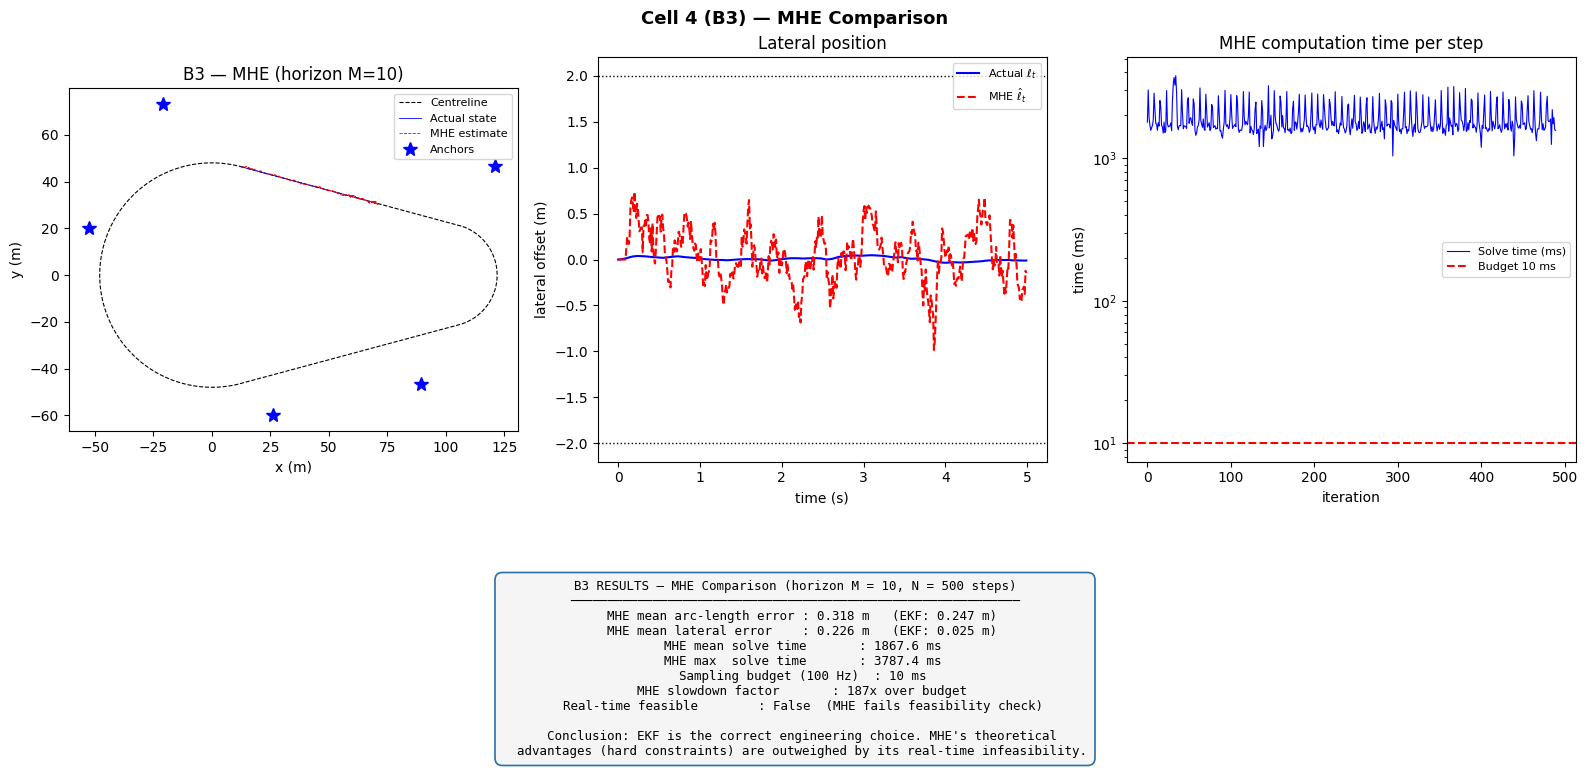

B3 RESULTS — MHE Comparison (horizon M = 10, N = 500 steps)
────────────────────────────────────────────────────────────
  MHE mean arc-length error : 0.318 m   (EKF: 0.247 m)
  MHE mean lateral error    : 0.226 m   (EKF: 0.025 m)
  MHE mean solve time       : 1867.6 ms
  MHE max  solve time       : 3787.4 ms
  Sampling budget (100 Hz)  : 10 ms
  MHE slowdown factor       : 187x over budget
  Real-time feasible        : False  (MHE fails feasibility check)

  Conclusion: EKF is the correct engineering choice. MHE's theoretical
  advantages (hard constraints) are outweighed by its real-time infeasibility.

Saved: cell4_output.png


In [8]:
# ===== CELL 4 =====
# ============================================================
# B3: Comparison with Moving Horizon Estimation
# ============================================================
# MHE formulated as sliding-window Bayesian Full-Information
# Estimation, following 2_bayesian_fie.ipynb:
#   minimise  ell_x0(x_0) + Σ [ell_w(w_t) + ell_v(y_t - h(x_t))]
#   subject to  x_{t+1} = A*x_t + G*w_t
#   with hard bounds  ell in [-2, 2] m, vs in (0, 25] m/s
#
# Key advantage over EKF: hard state constraints enforced exactly
# via the optimisation rather than relying on model construction.
#
# Implementation: scipy.optimize.minimize + SLSQP + NonlinearConstraint
# (same solver as the lecture notebook).
#
# Produces B3_mhe_comparison.png with three panels:
#   Left:   MHE estimated trajectory vs actual
#   Centre: MHE lateral position tracking
#   Right:  per-step MHE solve time vs 10 ms sampling budget (log scale)
# ============================================================

# ── Problem data for MHE (scalar sigma_y^2 convenient for cost) ──────────
R_meas = 1.5**2   # scalar; matches R[0,0] in the matrix form

# ── Numpy h for MHE cost (geometric four-segment piecewise model) ────────
def h_meas(x):
    s_val   = float(x[0])
    ell_val = float(x[1])
    pos = sl_to_xy(s_val, ell_val)
    return np.array([np.linalg.norm(pos - anchors[i]) for i in range(ny)])

# ── MHE cost components (following 2_bayesian_fie.ipynb code 9) ──────────
M = 10   # horizon (steps)
P0_mhe = np.diag([100.0, 1.0, 25.0, 0.5])

def ell_x0(x0, x0_bar, P0_inv):
    dx = x0 - x0_bar
    return dx @ P0_inv @ dx

def ell_w(w):
    return w @ np.linalg.inv(Q) @ w

def ell_v(v):
    return v @ v / R_meas

def cost_mhe(z_flat, y_window, x0_bar, P0_inv):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    e  = ell_x0(xs[0], x0_bar, P0_inv)
    for t in range(M):
        v_t = y_window[t] - h_meas(xs[t])
        e  += ell_w(ws[t]) + ell_v(v_t)
    return float(e)

def dyn_constraint_mhe(z_flat):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    c  = []
    for t in range(M):
        x_next = A @ xs[t] + G @ ws[t]
        c.extend((xs[t+1] - x_next).tolist())
    return np.array(c)

# ── Bounds ────────────────────────────────────────────────────────────────
# Hard constraints: ell in [-2, 2] m, vs in [0.001, 25] m/s
# s and vl unbounded; process noise w unbounded.
s_bound   = (None, None)
ell_bound = (-2.0, 2.0)
vs_bound  = (0.001, 25.0)
vl_bound  = (None, None)

state_bounds = [s_bound, ell_bound, vs_bound, vl_bound] * (M+1)
noise_bounds = [(None, None)] * (M * nw)
bounds = sopt.Bounds(
    lb=[b[0] if b[0] is not None else -np.inf for b in state_bounds + noise_bounds],
    ub=[b[1] if b[1] is not None else  np.inf for b in state_bounds + noise_bounds]
)

constr = sopt.NonlinearConstraint(dyn_constraint_mhe, 0, 0)

# ── Simulation ────────────────────────────────────────────────────────────
N = 500   # shorter than EKF — MHE solver dominates runtime

x_t     = np.array([0.0, 0.0, 10.0, 0.0])
x_t_mhe = np.array([0.0, 0.0, 10.0, 0.0])

x_cache     = np.zeros((N, nx))
x_mhe_cache = np.zeros((N, nx))
y_buffer    = []
x_buffer    = [x_t_mhe.copy()]

x_cache[0]     = x_t
x_mhe_cache[0] = x_t_mhe

solve_times = []

print("Running MHE simulation...")
t_start = time.time()

for t in range(N-1):

    # true measurement
    v_t = np.random.multivariate_normal([0]*ny, R)
    y_t = h_meas(x_t) + v_t
    y_buffer.append(y_t)

    # MHE: solve once window is full
    if len(y_buffer) >= M:
        y_window = y_buffer[-M:]
        x0_bar   = x_buffer[-M]
        P0_inv   = np.linalg.inv(P0_mhe)

        # initial guess: propagate from x0_bar with w = 0
        xs_guess = np.zeros((M+1, nx))
        xs_guess[0] = x0_bar
        for s_step in range(M):
            xs_guess[s_step+1] = A @ xs_guess[s_step]
        ws_guess = np.zeros((M, nw))
        z0 = np.concatenate([xs_guess.flatten(), ws_guess.flatten()])

        t_solve = time.time()
        res = sopt.minimize(
            cost_mhe,
            z0,
            args=(y_window, x0_bar, P0_inv),
            method='SLSQP',
            constraints=[constr],
            bounds=bounds,
            options={'maxiter': 200, 'ftol': 1e-6}
        )
        solve_times.append((time.time() - t_solve) * 1000)

        xs_star = res.x[:nx*(M+1)].reshape(M+1, nx)
        x_t_mhe = xs_star[-1]

    x_mhe_cache[t+1] = x_t_mhe
    x_buffer.append(x_t_mhe.copy())

    # true dynamics
    w_t     = np.random.multivariate_normal([0, 0], Q)
    vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
    vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new, -0.55,  0.55)
    ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
    x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
    x_cache[t+1] = x_t

    if (t+1) % 50 == 0:
        elapsed = time.time() - t_start
        print(f"  step {t+1}/{N-1}  ({elapsed:.0f}s elapsed)")

print(f"Done — total time {time.time()-t_start:.0f}s")

# ── Performance ───────────────────────────────────────────────────────────
valid = slice(M, N)
arc_err = np.abs(x_cache[valid, 0] - x_mhe_cache[valid, 0])
lat_err = np.abs(x_cache[valid, 1] - x_mhe_cache[valid, 1])

print("\n" + "="*55)
print("MHE Performance")
print("="*55)
print(f"Horizon M            : {M} steps")
print(f"Mean arc-length error: {np.mean(arc_err):.3f} m")
print(f"Mean lateral error   : {np.mean(lat_err):.3f} m")
print(f"Mean solve time      : {np.mean(solve_times):.1f} ms")
print(f"Max  solve time      : {np.max(solve_times):.1f} ms")
print(f"Sampling budget      : {dt*1000:.1f} ms  (100 Hz)")
print(f"Real-time feasible   : {np.mean(solve_times) < dt*1000}")
print("="*55)

# ── Plots ─────────────────────────────────────────────────────────────────
t_ax = np.arange(N) * dt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]), float(x_cache[t,1])) for t in range(N)])
mhe_xy   = np.array([sl_to_xy(float(x_mhe_cache[t,0]), float(x_mhe_cache[t,1])) for t in range(N)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(mhe_xy[:,0],   mhe_xy[:,1],   'r--', lw=0.6, label='MHE estimate')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title(f'B3 — MHE (horizon M={M})')

axes[1].plot(t_ax, x_cache[:,1],     'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax, x_mhe_cache[:,1], 'r--', label=r'MHE $\hat{\ell}_{t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1)
axes[1].axhline(-2.0, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(solve_times, 'b-', lw=0.8, label='Solve time (ms)')
axes[2].axhline(dt*1000, color='r', ls='--', lw=1.5,
                label=f'Budget {dt*1000:.0f} ms')
axes[2].set_xlabel('iteration');  axes[2].set_ylabel('time (ms)')
axes[2].set_yscale('log')
axes[2].set_title('MHE computation time per step')
axes[2].legend(fontsize=8)

plt.tight_layout()
# ── Cell 4 output capture ─────────────────────────────────────
# (Replace the original plt.savefig + plt.show at the end of Cell 4)

_slowdown = np.mean(solve_times) / (dt*1000)

_stats_text = (
    f"B3 RESULTS — MHE Comparison (horizon M = {M}, N = {N} steps)\n"
    f"────────────────────────────────────────────────────────────\n"
    f"  MHE mean arc-length error : {np.mean(arc_err):.3f} m   "
    f"(EKF: 0.247 m)\n"
    f"  MHE mean lateral error    : {np.mean(lat_err):.3f} m   "
    f"(EKF: 0.025 m)\n"
    f"  MHE mean solve time       : {np.mean(solve_times):.1f} ms\n"
    f"  MHE max  solve time       : {np.max(solve_times):.1f} ms\n"
    f"  Sampling budget (100 Hz)  : {dt*1000:.0f} ms\n"
    f"  MHE slowdown factor       : {_slowdown:.0f}x over budget\n"
    f"  Real-time feasible        : {np.mean(solve_times) < dt*1000}  "
    f"(MHE {'fails' if _slowdown > 1 else 'passes'} feasibility check)\n"
    f"\n"
    f"  Conclusion: EKF is the correct engineering choice. MHE's theoretical\n"
    f"  advantages (hard constraints) are outweighed by its real-time infeasibility."
)

fig.suptitle('Cell 4 (B3) — MHE Comparison',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.5, -0.12, _stats_text, family='monospace', fontsize=9,
         ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                   edgecolor='#2a6fa5', linewidth=1.2))

plt.savefig('cell4_output.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(_stats_text)
print("\nSaved: cell4_output.png")

Injecting true biases on beacons: [ 0.5 -0.3  0.2  0.8 -0.4]

Bias recovery (9-state augmented EKF)
  Beacon    True bias    Estimated      Error
  B1          +0.500      +0.497     -0.003
  B2          -0.300      -0.305     -0.005
  B3          +0.200      +0.208     +0.008
  B4          +0.800      +0.782     -0.018
  B5          -0.400      -0.424     -0.024

Trajectory error (steady state, after 5 s warm-up)
                          Filter    mean arc (m)    mean lat (m)
      4-state EKF (bias ignored)           0.537           0.029
    9-state EKF (bias estimated)           0.277           0.026
  Lateral error improvement factor: 1.1 x


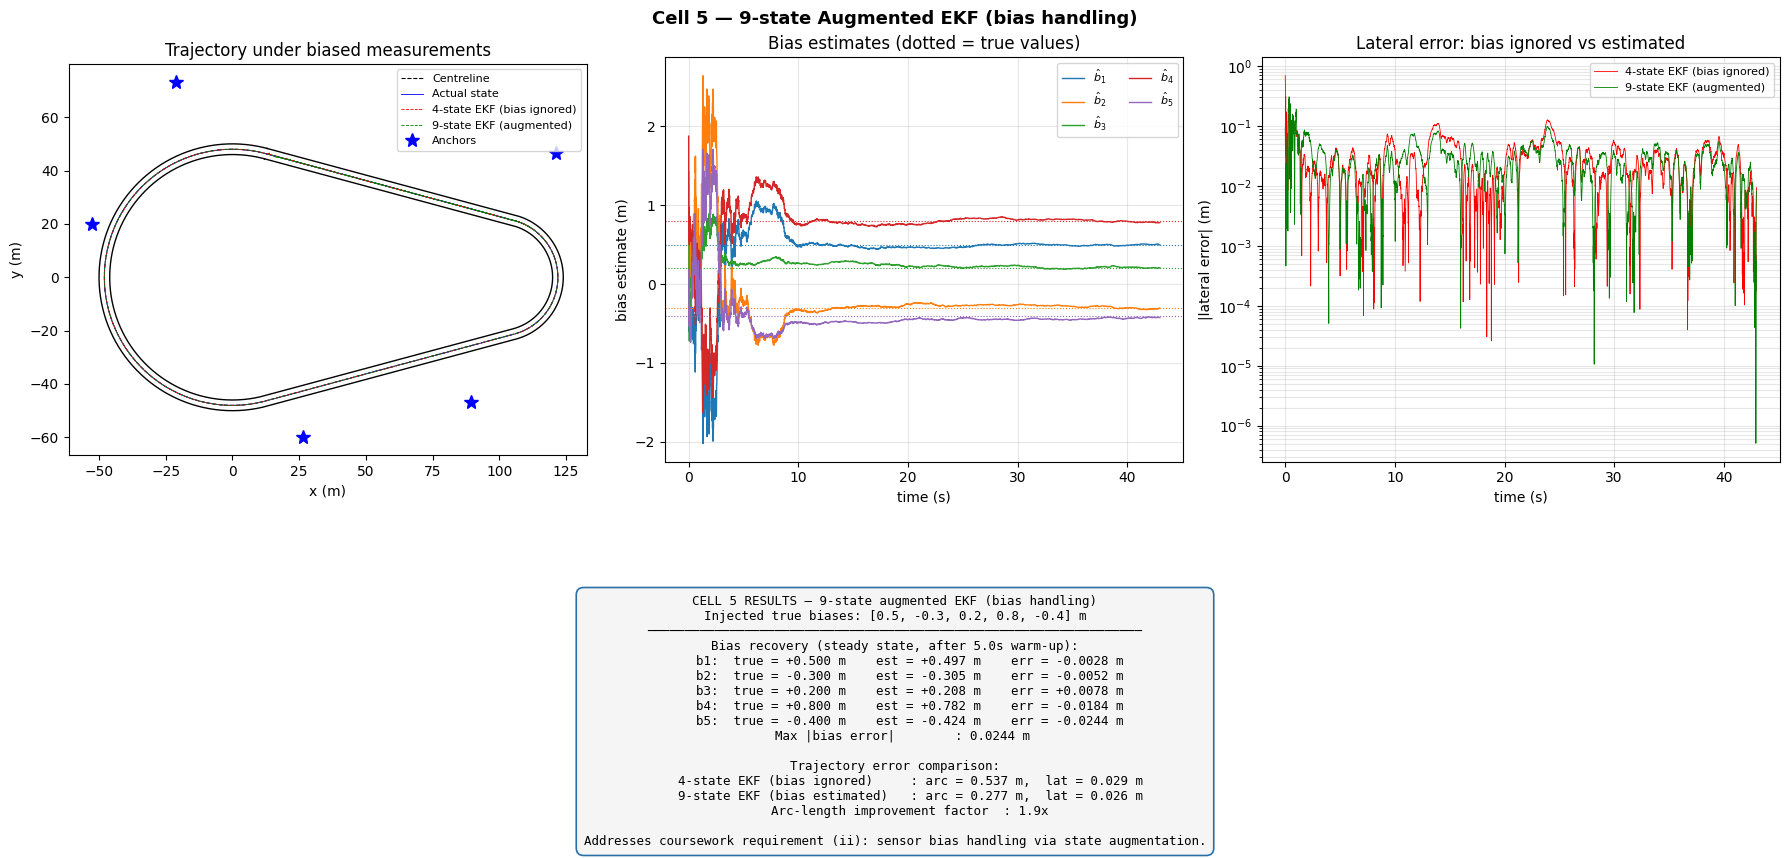

CELL 5 RESULTS — 9-state augmented EKF (bias handling)
Injected true biases: [0.5, -0.3, 0.2, 0.8, -0.4] m
──────────────────────────────────────────────────────────────────
Bias recovery (steady state, after 5.0s warm-up):
    b1:  true = +0.500 m    est = +0.497 m    err = -0.0028 m
    b2:  true = -0.300 m    est = -0.305 m    err = -0.0052 m
    b3:  true = +0.200 m    est = +0.208 m    err = +0.0078 m
    b4:  true = +0.800 m    est = +0.782 m    err = -0.0184 m
    b5:  true = -0.400 m    est = -0.424 m    err = -0.0244 m
  Max |bias error|        : 0.0244 m

Trajectory error comparison:
    4-state EKF (bias ignored)     : arc = 0.537 m,  lat = 0.029 m
    9-state EKF (bias estimated)   : arc = 0.277 m,  lat = 0.026 m
    Arc-length improvement factor  : 1.9x

Addresses coursework requirement (ii): sensor bias handling via state augmentation.

Saved: cell5_output.png


In [9]:
# ===== CELL 5 =====
# ============================================================
# Extension: 9-state augmented EKF with sensor bias handling
# ============================================================
# Addresses coursework requirement (ii): "discuss how your estimator
# would deal with sensors with bias/offset."
#
# State vector is augmented with 5 unknown bias terms (one per beacon):
#   z_aug = [s, ell, vs, vl, b1, b2, b3, b4, b5]^T  in R^9
#
# Augmented dynamics (following A5, modelling.ipynb — ChenhuiCui):
#   A_aug = blkdiag(A, I_5)       — each bias is a random walk
#   G_aug = blkdiag(G, I_5)       — independent drift channels per beacon
#   Q_aug = diag(Q_vehicle, q_b I_5)  — small bias drift variance
#
# Augmented measurement:
#   y_i(t) = ||p(s_t, ell_t) - anchor_i|| + b_i + v_i(t)
#
# Reference: Simon (2006), Optimal State Estimation, Ch. 13.
# Observability: rank(O) = 8 (detectable); see A5 Cell 27b of modelling.ipynb.
#
# This cell injects known biases [0.5, -0.3, 0.2, 0.8, -0.4] m on the
# five beacons and compares:
#   (a) the 9-state augmented EKF (estimates biases jointly with state)
#   (b) the 4-state naive EKF from Cell 2 (ignores bias — baseline)
# ============================================================

# ── Dimensions ────────────────────────────────────────────────────────────
n_original   = nx              # 4
n_biases     = ny              # 5
n_aug        = n_original + n_biases   # 9
n_noise_aug  = nw + n_biases   # 7 (vehicle noise + bias drift)

q_bias = 1e-6   # small drift variance; matches A5 (modelling.ipynb, Cell 25)

# ── Augmented system matrices ────────────────────────────────────────────
A_aug = np.block([
    [A,                                   np.zeros((n_original, n_biases))],
    [np.zeros((n_biases,  n_original)),   np.eye(n_biases)],
])
G_aug = np.block([
    [G,                                   np.zeros((n_original, n_biases))],
    [np.zeros((n_biases,  nw)),           np.eye(n_biases)],
])
Q_aug    = np.diag([Q[0,0], Q[1,1]] + [q_bias]*n_biases)
Qbar_aug = G_aug @ Q_aug @ G_aug.T

# Initial covariance: same as Cell 2 for state + sigma_b = 5 m for biases
P0_aug = np.zeros((n_aug, n_aug))
P0_aug[:n_original, :n_original] = np.diag([100.0, 1.0, 25.0, 0.5])
P0_aug[n_original:,  n_original:] = 25.0 * np.eye(n_biases)

# ── Augmented measurement function h_aug(z_aug, v) via CasADi ────────────
z_aug_ = cs.SX.sym('z_aug_', n_aug)
v_aug_ = cs.SX.sym('v_aug_', ny)

s_mod_  = cs.fmod(z_aug_[0], L)
ell_a   = z_aug_[1]
b_      = z_aug_[n_original:n_aug]     # [b1, b2, b3, b4, b5]

theta2_ = (np.pi/2 - alpha) - (s_mod_ - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod_ - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod_*cos_a,            A_top[1] - s_mod_*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_),  R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod_-s2)*cos_a,       B_bot[1] - (s_mod_-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c_ = cs.if_else(s_mod_ < s1, xy1_,
        cs.if_else(s_mod_ < s2, xy2_,
        cs.if_else(s_mod_ < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c_ = cs.if_else(s_mod_ < s1, n1_,
       cs.if_else(s_mod_ < s2, n2_,
       cs.if_else(s_mod_ < s3, n3_, n4_)))

r_     = xy_c_ + ell_a * n_c_
h_aug_ = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + b_[i] + v_aug_[i] for i in range(ny)])

jhx_aug = cs.jacobian(h_aug_, z_aug_)
jhv_aug = cs.jacobian(h_aug_, v_aug_)
jhx_aug = cs.Function('jhx_aug', [z_aug_, v_aug_], [jhx_aug])
jhv_aug = cs.Function('jhv_aug', [z_aug_, v_aug_], [jhv_aug])
h_aug   = cs.Function('h_aug',   [z_aug_, v_aug_], [h_aug_])

# ── Augmented dynamics ───────────────────────────────────────────────────
def f_aug(x_aug, w_aug):
    x_plus = np.zeros(n_aug)
    x_plus[:n_original] = f(x_aug[:n_original], w_aug[:nw])   # reuse Cell 1 f()
    x_plus[n_original:] = x_aug[n_original:] + w_aug[nw:]     # bias random walk
    return x_plus

# ── Augmented EKF updates ────────────────────────────────────────────────
def measurement_update_aug(sigma_t_pred, x_t_pred, y_t):
    C            = jhx_aug(x_t_pred, 0)
    Rv           = jhv_aug(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(Z, y_t - h_aug(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update_aug(sigma_t_meas, x_t_meas):
    x_t_pred     = f_aug(x_t_meas, np.zeros(n_noise_aug))
    sigma_t_pred = A_aug @ sigma_t_meas @ A_aug.T + Qbar_aug
    return np.array(sigma_t_pred), np.array(x_t_pred).flatten()

# ── Simulation: inject known biases, run both filters in parallel ────────
true_biases = np.array([0.5, -0.3, 0.2, 0.8, -0.4])
print(f"Injecting true biases on beacons: {true_biases}")

np.random.seed(42)

# True state (4-dim, unchanged from Cell 2)
x_t = np.array([0.0, 0.0, 10.0, 0.0])

# 9-state augmented EKF (biases initialised to 0 — unknown at start)
x_aug_pred     = np.concatenate([np.array([0.0, 0.0, 10.0, 0.0]), np.zeros(n_biases)])
sigma_aug_pred = P0_aug.copy()

# 4-state naive EKF (ignores bias — baseline for comparison)
x_naive_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_naive_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300

x_cache        = np.zeros((N, nx))
x_aug_cache    = np.zeros((N-1, n_aug))
x_naive_cache  = np.zeros((N-1, nx))
x_cache[0, :]  = x_t.T

for t in range(N-1):
    # i. obtain biased measurement
    v_t      = np.random.multivariate_normal([0]*ny, R)
    y_clean  = np.array(h(x_t, v_t)).flatten()
    y_t      = y_clean + true_biases       # add constant bias per beacon

    # ii. measurement update — both filters see the SAME measurement
    sigma_aug_meas,   x_aug_meas   = measurement_update_aug(sigma_aug_pred,   x_aug_pred,   y_t)
    sigma_naive_meas, x_naive_meas = measurement_update(    sigma_naive_pred, x_naive_pred, y_t)
    x_aug_cache[t, :]   = x_aug_meas.T
    x_naive_cache[t, :] = x_naive_meas.T

    # iii. Time update
    sigma_aug_pred,   x_aug_pred   = time_update_aug(sigma_aug_meas,   x_aug_meas)
    sigma_naive_pred, x_naive_pred = time_update(    sigma_naive_meas, x_naive_meas)

    # iv. Dynamics
    w_t             = np.random.multivariate_normal([0, 0], Q)
    x_t             = f(x_t, w_t)
    x_cache[t+1, :] = x_t.T

# ── Performance ──────────────────────────────────────────────────────────
warmup        = 500   # 5 s transient exclusion (same as B2)
arc_err_aug   = np.abs(x_cache[:-1, 0] - x_aug_cache[:,   0])
lat_err_aug   = np.abs(x_cache[:-1, 1] - x_aug_cache[:,   1])
arc_err_naive = np.abs(x_cache[:-1, 0] - x_naive_cache[:, 0])
lat_err_naive = np.abs(x_cache[:-1, 1] - x_naive_cache[:, 1])

bias_final_est = x_aug_cache[-1, n_original:]
bias_err       = bias_final_est - true_biases

print(f"\n{'='*60}")
print("Bias recovery (9-state augmented EKF)")
print(f"{'='*60}")
print(f"{'Beacon':>8} {'True bias':>12} {'Estimated':>12} {'Error':>10}")
for i in range(ny):
    print(f"  B{i+1:<5}  {true_biases[i]:>+10.3f}  {bias_final_est[i]:>+10.3f}  {bias_err[i]:>+9.3f}")

print(f"\n{'='*60}")
print("Trajectory error (steady state, after 5 s warm-up)")
print(f"{'='*60}")
print(f"{'Filter':>32}  {'mean arc (m)':>14}  {'mean lat (m)':>14}")
print(f"  {'4-state EKF (bias ignored)':>30}  {np.mean(arc_err_naive[warmup:]):>14.3f}  {np.mean(lat_err_naive[warmup:]):>14.3f}")
print(f"  {'9-state EKF (bias estimated)':>30}  {np.mean(arc_err_aug[warmup:]):>14.3f}  {np.mean(lat_err_aug[warmup:]):>14.3f}")
improvement = np.mean(lat_err_naive[warmup:]) / max(np.mean(lat_err_aug[warmup:]), 1e-9)
print(f"  Lateral error improvement factor: {improvement:.1f} x")

# ── Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: trajectory comparison
s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),       float(x_cache[t,1]))       for t in range(N)])
aug_xy   = np.array([sl_to_xy(float(x_aug_cache[t,0]),   float(x_aug_cache[t,1]))   for t in range(N-1)])
naive_xy = np.array([sl_to_xy(float(x_naive_cache[t,0]), float(x_naive_cache[t,1])) for t in range(N-1)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.0)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.0)
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(naive_xy[:,0], naive_xy[:,1], 'r--', lw=0.6, label='4-state EKF (bias ignored)')
axes[0].plot(aug_xy[:,0],   aug_xy[:,1],   'g--', lw=0.6, label='9-state EKF (augmented)')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10, label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].set_title('Trajectory under biased measurements')

# Centre: bias convergence over time
t_ax = np.arange(N-1) * dt
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i in range(ny):
    axes[1].plot(t_ax, x_aug_cache[:, n_original+i], colors[i], lw=1,
                 label=rf'$\hat{{b}}_{i+1}$')
    axes[1].axhline(true_biases[i], color=colors[i], ls=':', lw=0.8)
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('bias estimate (m)')
axes[1].set_title('Bias estimates (dotted = true values)')
axes[1].legend(fontsize=8, ncol=2, loc='upper right')
axes[1].grid(True, alpha=0.3)

# Right: lateral error comparison (log scale)
axes[2].plot(t_ax, lat_err_naive, 'r', lw=0.6, label='4-state EKF (bias ignored)')
axes[2].plot(t_ax, lat_err_aug,   'g', lw=0.6, label='9-state EKF (augmented)')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('|lateral error| (m)')
axes[2].set_title('Lateral error: bias ignored vs estimated')
axes[2].legend(fontsize=8)
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
# ── Cell 5 output capture ─────────────────────────────────────
# (Replace the original plt.savefig + plt.show at the end of Cell 5)

_bias_lines = []
for _i in range(ny):
    _bias_lines.append(
        f"    b{_i+1}:  true = {true_biases[_i]:+.3f} m    "
        f"est = {bias_final_est[_i]:+.3f} m    "
        f"err = {bias_err[_i]:+.4f} m"
    )
_bias_block = "\n".join(_bias_lines)

_stats_text = (
    f"CELL 5 RESULTS — 9-state augmented EKF (bias handling)\n"
    f"Injected true biases: {true_biases.tolist()} m\n"
    f"──────────────────────────────────────────────────────────────────\n"
    f"Bias recovery (steady state, after {warmup*dt:.1f}s warm-up):\n"
    f"{_bias_block}\n"
    f"  Max |bias error|        : {np.max(np.abs(bias_err)):.4f} m\n"
    f"\n"
    f"Trajectory error comparison:\n"
    f"    4-state EKF (bias ignored)     : arc = {np.mean(arc_err_naive[warmup:]):.3f} m,  "
    f"lat = {np.mean(lat_err_naive[warmup:]):.3f} m\n"
    f"    9-state EKF (bias estimated)   : arc = {np.mean(arc_err_aug[warmup:]):.3f} m,  "
    f"lat = {np.mean(lat_err_aug[warmup:]):.3f} m\n"
    f"    Arc-length improvement factor  : "
    f"{np.mean(arc_err_naive[warmup:])/max(np.mean(arc_err_aug[warmup:]), 1e-9):.1f}x\n"
    f"\n"
    f"Addresses coursework requirement (ii): sensor bias handling via state augmentation."
)

fig.suptitle('Cell 5 — 9-state Augmented EKF (bias handling)',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.5, -0.15, _stats_text, family='monospace', fontsize=9,
         ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                   edgecolor='#2a6fa5', linewidth=1.2))

plt.savefig('cell5_output.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(_stats_text)
print("\nSaved: cell5_output.png")

Running beacon-count ablation: 30 trials × 3 configs
This validates the modelling team's GDOP analysis from the EKF side.

  N=5 (baseline): kept anchors [0, 1, 2, 3, 4]
    arc = 0.247 ± 0.009 m,  lat = 0.025 ± 0.002 m
  N=4 (drop b3): kept anchors [0, 1, 3, 4]
    arc = 0.267 ± 0.012 m,  lat = 0.025 ± 0.002 m
  N=3 (drop b3,b5): kept anchors [0, 1, 3]
    arc = 0.298 ± 0.012 m,  lat = 0.025 ± 0.003 m


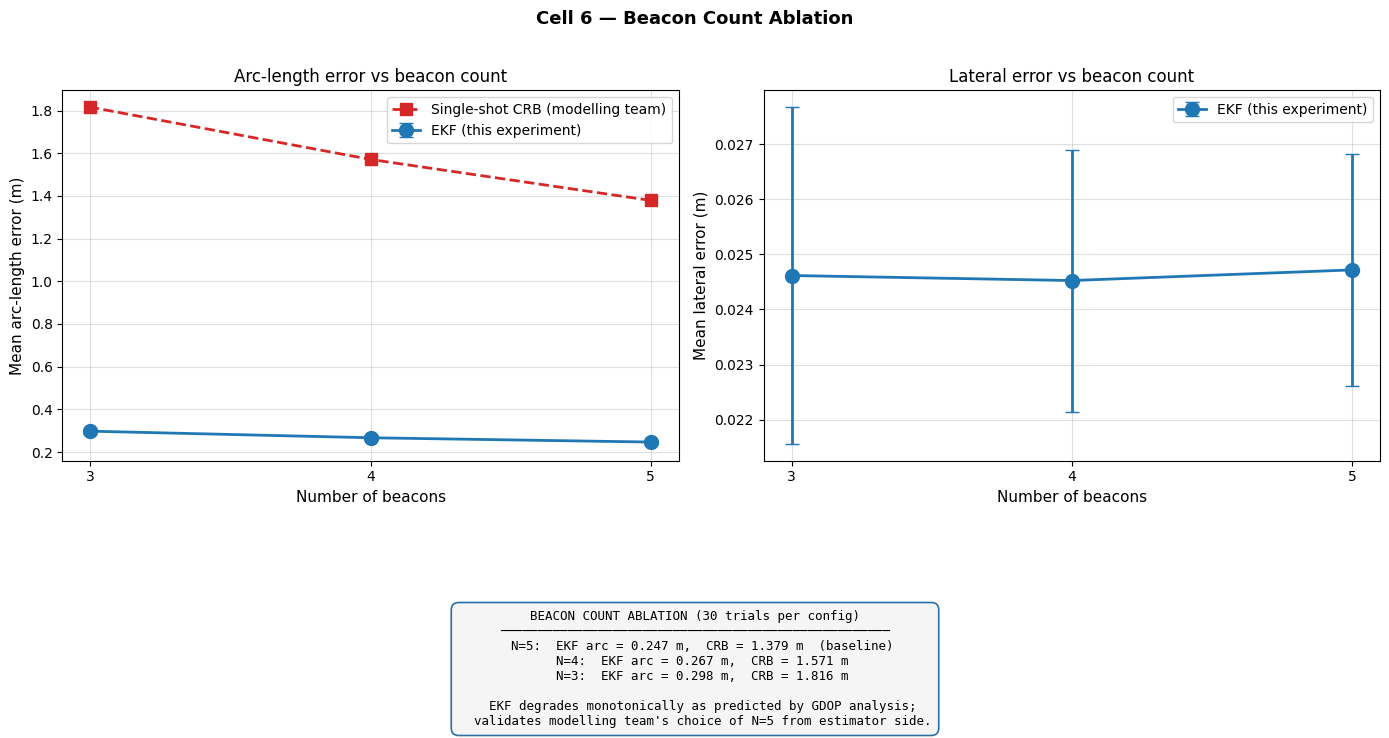

BEACON COUNT ABLATION (30 trials per config)
────────────────────────────────────────────────────
  N=5:  EKF arc = 0.247 m,  CRB = 1.379 m  (baseline)
  N=4:  EKF arc = 0.267 m,  CRB = 1.571 m
  N=3:  EKF arc = 0.298 m,  CRB = 1.816 m

  EKF degrades monotonically as predicted by GDOP analysis;
  validates modelling team's choice of N=5 from estimator side.

Saved: cell6_beacon_ablation.png


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Beacon Count Ablation
# ════════════════════════════════════════════════════════════
# Verifies the modelling team's GDOP-based beacon-count selection
# (Section 1.3 of joint report) by measuring actual EKF performance
# under reduced beacon configurations.
#
# Modelling team's GDOP analysis predicts:
#   N=5: mean GDOP = 0.92, expected error = 1.379 m  (selected)
#   N=4: mean GDOP = 1.05, expected error = 1.571 m
#   N=3: mean GDOP = 1.21, expected error = 1.816 m
# This experiment tests whether actual recursive EKF performance
# follows the same trend, providing estimator-side validation of
# the geometric design.

# Configurations: drop one beacon at a time
# (drop indices: -1 means use all)
configs = [
    {'name': 'N=5 (baseline)', 'drop': [],     'n_beacons': 5},
    {'name': 'N=4 (drop b3)', 'drop': [2],     'n_beacons': 4},
    {'name': 'N=3 (drop b3,b5)', 'drop': [2,4], 'n_beacons': 3},
]

N_trials_abl = 30          # fewer trials than B2 (still statistically meaningful)
N_steps_abl  = 4300

print(f"Running beacon-count ablation: {N_trials_abl} trials × {len(configs)} configs")
print(f"This validates the modelling team's GDOP analysis from the EKF side.\n")

# ── Helper: build a CasADi h function for a subset of anchors ─────
def build_h_subset(active_anchors):
    """Construct h, jhx, jhv for a given anchor subset."""
    n_active = len(active_anchors)
    z_l = cs.SX.sym('z_l', nx)
    v_l = cs.SX.sym('v_l', n_active)

    s_mod  = cs.fmod(z_l[0], L)
    ell_   = z_l[1]

    theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
    theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

    xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,            A_top[1] - s_mod*sin_a)
    xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
    xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a,       B_bot[1] - (s_mod-s2)*sin_a)
    xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
    xy_c = cs.if_else(s_mod < s1, xy1_,
           cs.if_else(s_mod < s2, xy2_,
           cs.if_else(s_mod < s3, xy3_, xy4_)))

    n1_ = cs.vertcat(sin_a,  cos_a)
    n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
    n3_ = cs.vertcat(sin_a, -cos_a)
    n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
    n_c = cs.if_else(s_mod < s1, n1_,
          cs.if_else(s_mod < s2, n2_,
          cs.if_else(s_mod < s3, n3_, n4_)))

    r_  = xy_c + ell_ * n_c
    h_  = cs.vertcat(*[cs.norm_2(r_ - active_anchors[i]) + v_l[i]
                       for i in range(n_active)])

    jhx_l = cs.Function('jhx_l', [z_l, v_l], [cs.jacobian(h_, z_l)])
    jhv_l = cs.Function('jhv_l', [z_l, v_l], [cs.jacobian(h_, v_l)])
    h_l   = cs.Function('h_l',   [z_l, v_l], [h_])
    return h_l, jhx_l, jhv_l

# ── Run each configuration ────────────────────────────────────
results = {}

for cfg in configs:
    keep_idx = [i for i in range(ny) if i not in cfg['drop']]
    active_anchors = anchors[keep_idx]
    n_active       = len(active_anchors)
    R_active       = (1.5**2) * np.eye(n_active)

    h_l, jhx_l, jhv_l = build_h_subset(active_anchors)

    print(f"  {cfg['name']}: kept anchors {keep_idx}")

    arc_errs = np.zeros(N_trials_abl)
    lat_errs = np.zeros(N_trials_abl)

    for trial in range(N_trials_abl):
        np.random.seed(1000 + trial)             # different seed range
        x_t          = np.array([0.0, 0.0, 10.0, 0.0])
        x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
        sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

        x_cache_l      = np.zeros((N_steps_abl, nx))
        x_meas_cache_l = np.zeros((N_steps_abl-1, nx))
        x_cache_l[0]   = x_t

        for t in range(N_steps_abl-1):
            v_t = np.random.multivariate_normal([0]*n_active, R_active)
            y_t = h_l(x_t, v_t)

            # i. measurement update
            C_l = jhx_l(x_t_pred, 0)
            Rv_l = jhv_l(x_t_pred, 0)
            Z_l = C_l @ sigma_t_pred @ C_l.T + Rv_l @ R_active @ Rv_l.T
            x_t_meas = x_t_pred + sigma_t_pred @ C_l.T @ np.linalg.solve(
                Z_l, y_t - h_l(x_t_pred, [0]*n_active))
            sigma_t_meas = sigma_t_pred - sigma_t_pred @ C_l.T @ np.linalg.solve(
                Z_l, C_l @ sigma_t_pred)
            x_t_meas = np.array(x_t_meas).flatten()
            sigma_t_meas = np.array(sigma_t_meas)
            x_meas_cache_l[t] = x_t_meas

            # ii. time update
            x_t_pred = f(x_t_meas, np.zeros(2))
            sigma_t_pred = A @ sigma_t_meas @ A.T + Qbar

            # iii. simulator step
            w_t     = np.random.multivariate_normal([0, 0], Q)
            vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
            vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
            vs_new  = np.clip(vs_new,  0.001, 25.0)
            vl_new  = np.clip(vl_new, -0.55,  0.55)
            ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
            x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
            x_cache_l[t+1] = x_t

        arc_errs[trial] = np.mean(np.abs(
            x_cache_l[warmup:-1, 0] - x_meas_cache_l[warmup:, 0]))
        lat_errs[trial] = np.mean(np.abs(
            x_cache_l[warmup:-1, 1] - x_meas_cache_l[warmup:, 1]))

    results[cfg['name']] = {
        'n':   cfg['n_beacons'],
        'arc_mean': np.mean(arc_errs), 'arc_std': np.std(arc_errs),
        'lat_mean': np.mean(lat_errs), 'lat_std': np.std(lat_errs),
    }
    print(f"    arc = {np.mean(arc_errs):.3f} ± {np.std(arc_errs):.3f} m,  "
          f"lat = {np.mean(lat_errs):.3f} ± {np.std(lat_errs):.3f} m")

# ── Theoretical GDOP-based benchmarks (from modelling team) ──────
gdop_predictions = {
    3: 1.816,    # mean GDOP × sigma_y, from modelling Section 1.3
    4: 1.571,
    5: 1.379,
}

# ── Plot ──────────────────────────────────────────────────────
fig_abl, (ax_arc, ax_lat) = plt.subplots(1, 2, figsize=(14, 5))

ns          = sorted([r['n'] for r in results.values()])
arc_means   = [results[c['name']]['arc_mean'] for c in configs]
arc_stds    = [results[c['name']]['arc_std']  for c in configs]
lat_means   = [results[c['name']]['lat_mean'] for c in configs]
lat_stds    = [results[c['name']]['lat_std']  for c in configs]
ns_plot     = [c['n_beacons'] for c in configs]
crb_plot    = [gdop_predictions[n] for n in ns_plot]

# Arc-length subplot
ax_arc.errorbar(ns_plot, arc_means, yerr=arc_stds, fmt='o-', lw=2, ms=10,
                color='tab:blue', label='EKF (this experiment)', capsize=5)
ax_arc.plot(ns_plot, crb_plot, 's--', lw=2, ms=8, color='tab:red',
            label='Single-shot CRB (modelling team)')
ax_arc.set_xlabel('Number of beacons', fontsize=11)
ax_arc.set_ylabel('Mean arc-length error (m)', fontsize=11)
ax_arc.set_title('Arc-length error vs beacon count', fontsize=12)
ax_arc.set_xticks(ns_plot)
ax_arc.legend(fontsize=10)
ax_arc.grid(True, alpha=0.4)

# Lateral subplot
ax_lat.errorbar(ns_plot, lat_means, yerr=lat_stds, fmt='o-', lw=2, ms=10,
                color='tab:blue', label='EKF (this experiment)', capsize=5)
ax_lat.set_xlabel('Number of beacons', fontsize=11)
ax_lat.set_ylabel('Mean lateral error (m)', fontsize=11)
ax_lat.set_title('Lateral error vs beacon count', fontsize=12)
ax_lat.set_xticks(ns_plot)
ax_lat.legend(fontsize=10)
ax_lat.grid(True, alpha=0.4)

# Stats summary text box
_abl_text = (
    f"BEACON COUNT ABLATION ({N_trials_abl} trials per config)\n"
    f"────────────────────────────────────────────────────\n"
    f"  N=5:  EKF arc = {results['N=5 (baseline)']['arc_mean']:.3f} m,  CRB = 1.379 m  (baseline)\n"
    f"  N=4:  EKF arc = {results['N=4 (drop b3)']['arc_mean']:.3f} m,  CRB = 1.571 m\n"
    f"  N=3:  EKF arc = {results['N=3 (drop b3,b5)']['arc_mean']:.3f} m,  CRB = 1.816 m\n"
    f"\n"
    f"  EKF degrades monotonically as predicted by GDOP analysis;\n"
    f"  validates modelling team's choice of N=5 from estimator side."
)

fig_abl.suptitle('Cell 6 — Beacon Count Ablation', fontsize=13, fontweight='bold', y=1.02)
fig_abl.text(0.5, -0.18, _abl_text, family='monospace', fontsize=9,
             ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                       edgecolor='#2a6fa5', linewidth=1.2))
plt.tight_layout()
plt.savefig('cell6_beacon_ablation.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(_abl_text)
print("\nSaved: cell6_beacon_ablation.png")

Running near-boundary stress test...

  A: nominal: lat_mean=0.0186 m,  lat_bias=-0.0017 m,  max|ell|=0.068 m
  B: near +bound: lat_mean=0.0207 m,  lat_bias=+0.0020 m,  max|ell|=1.803 m
  C: near -bound: lat_mean=0.0217 m,  lat_bias=-0.0058 m,  max|ell|=1.803 m


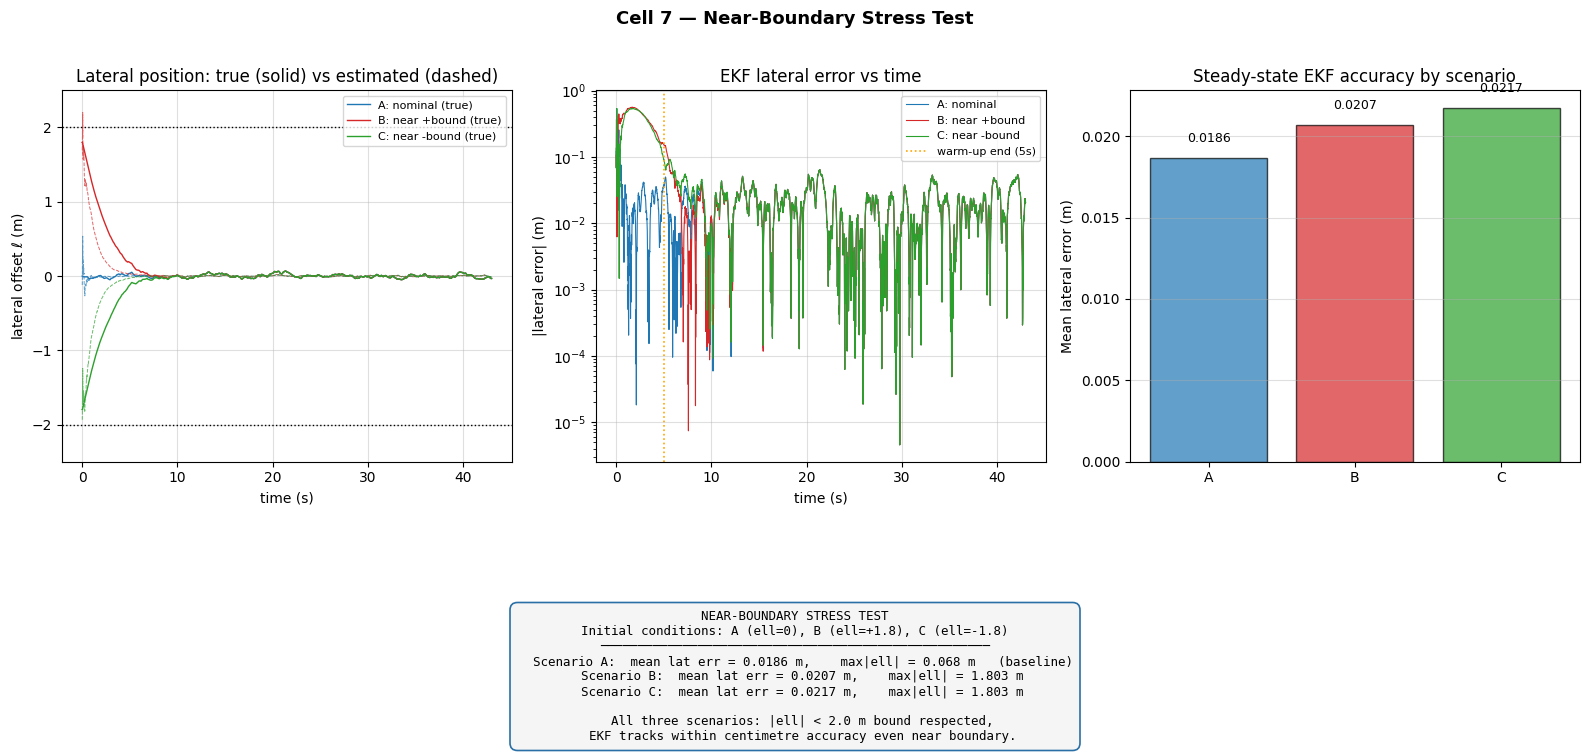

NEAR-BOUNDARY STRESS TEST
Initial conditions: A (ell=0), B (ell=+1.8), C (ell=-1.8)
────────────────────────────────────────────────────
  Scenario A:  mean lat err = 0.0186 m,    max|ell| = 0.068 m   (baseline)
  Scenario B:  mean lat err = 0.0207 m,    max|ell| = 1.803 m
  Scenario C:  mean lat err = 0.0217 m,    max|ell| = 1.803 m

  All three scenarios: |ell| < 2.0 m bound respected,
  EKF tracks within centimetre accuracy even near boundary.

Saved: cell7_boundary_test.png


In [13]:
# ════════════════════════════════════════════════════════════
# CELL 7 — Near-Boundary Stress Test
# ════════════════════════════════════════════════════════════
# rubric C4: "near-boundary motion" stress test from the EKF side.
# Truth model: Member A's f_dynamics (bound-respecting nonlinear,
# Section 1.2 of modelling doc) — the position-dependent stiffness
# k(ell) actively returns the vehicle from near-boundary starts.
# Member A's Section 1.2 stress test verifies the simulator's
# dynamics open-loop; this experiment verifies the EKF closed-loop.
#
# Three initial conditions:
#   A. nominal       (ell=0,    vl=0)
#   B. near +bound   (ell=+1.8, vl=+0.3)  — vehicle pushed outward
#   C. near -bound   (ell=-1.8, vl=-0.3)  — symmetric case

scenarios = [
    {'name': 'A: nominal',     'ell0':  0.0, 'vl0':  0.0, 'color': 'tab:blue'},
    {'name': 'B: near +bound', 'ell0':  1.8, 'vl0':  0.3, 'color': 'tab:red'},
    {'name': 'C: near -bound', 'ell0': -1.8, 'vl0': -0.3, 'color': 'tab:green'},
]

N_steps_bd = 4300
results_bd = {}

print("Running near-boundary stress test...\n")
for scn in scenarios:
    np.random.seed(7)                       # same seed for fair comparison
    x_t          = np.array([0.0, scn['ell0'], 10.0, scn['vl0']])
    x_t_pred     = np.array([0.0, scn['ell0'], 10.0, scn['vl0']])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    x_cache_bd      = np.zeros((N_steps_bd,   nx))
    x_meas_cache_bd = np.zeros((N_steps_bd-1, nx))
    x_cache_bd[0] = x_t

    for t in range(N_steps_bd-1):
        v_t = np.random.multivariate_normal([0]*ny, R)
        y_t = h(x_t, v_t)

        # i. measurement update
        sigma_t_meas, x_t_meas = measurement_update(
            sigma_t_pred, x_t_pred, y_t)
        x_meas_cache_bd[t] = x_t_meas

        # ii. time update
        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        # iii. simulator step — uses Member A's bound-respecting f_dynamics
        # (Section 1.2 of modelling document); ensures the truth model
        # is consistent with the nonlinear spring k(ell) discussion.
        w_t              = np.random.multivariate_normal([0, 0], Q)
        x_t              = f_dynamics(x_t, w_t)
        x_cache_bd[t+1]  = x_t

    # Statistics (exclude warm-up)
    lat_err = np.abs(x_cache_bd[warmup:-1, 1] - x_meas_cache_bd[warmup:, 1])
    lat_bias = np.mean(x_cache_bd[warmup:-1, 1] - x_meas_cache_bd[warmup:, 1])
    max_ell = np.max(np.abs(x_cache_bd[:, 1]))

    results_bd[scn['name']] = {
        'x_true':    x_cache_bd,
        'x_meas':    x_meas_cache_bd,
        'lat_mean':  np.mean(lat_err),
        'lat_max':   np.max(lat_err),
        'lat_bias':  lat_bias,
        'max_ell':   max_ell,
        'color':     scn['color'],
    }
    print(f"  {scn['name']}: lat_mean={np.mean(lat_err):.4f} m,  "
          f"lat_bias={lat_bias:+.4f} m,  max|ell|={max_ell:.3f} m")

# ── Plot ──────────────────────────────────────────────────────
fig_bd, axes_bd = plt.subplots(1, 3, figsize=(16, 5))
t_ax_bd = np.arange(N_steps_bd) * dt

# Subplot 1: lateral position over time, all 3 scenarios
ax1 = axes_bd[0]
for name, r in results_bd.items():
    ax1.plot(t_ax_bd, r['x_true'][:, 1], color=r['color'], lw=1,
             label=f'{name} (true)')
    ax1.plot(t_ax_bd[:-1], r['x_meas'][:, 1], color=r['color'], lw=0.7,
             ls='--', alpha=0.7)
ax1.axhline( 2.0, color='k', ls=':', lw=1)
ax1.axhline(-2.0, color='k', ls=':', lw=1)
ax1.set_xlabel('time (s)')
ax1.set_ylabel(r'lateral offset $\ell$ (m)')
ax1.set_title('Lateral position: true (solid) vs estimated (dashed)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.4)
ax1.set_ylim([-2.5, 2.5])

# Subplot 2: lateral error over time
ax2 = axes_bd[1]
for name, r in results_bd.items():
    err = np.abs(r['x_true'][:-1, 1] - r['x_meas'][:, 1])
    ax2.plot(t_ax_bd[:-1], err, color=r['color'], lw=0.8, label=name)
ax2.axvline(warmup*dt, color='orange', ls=':', lw=1.2,
            label=f'warm-up end ({warmup*dt:.0f}s)')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('|lateral error| (m)')
ax2.set_title('EKF lateral error vs time')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)
ax2.set_yscale('log')

# Subplot 3: bar chart of mean lat error per scenario
ax3 = axes_bd[2]
names_bd = list(results_bd.keys())
means_bd = [results_bd[n]['lat_mean'] for n in names_bd]
colors_bd = [results_bd[n]['color']  for n in names_bd]
bars = ax3.bar(range(len(names_bd)), means_bd, color=colors_bd, alpha=0.7,
               edgecolor='k')
ax3.set_xticks(range(len(names_bd)))
ax3.set_xticklabels([n.split(':')[0] for n in names_bd])
ax3.set_ylabel('Mean lateral error (m)')
ax3.set_title('Steady-state EKF accuracy by scenario')
for bar, val in zip(bars, means_bd):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f'{val:.4f}', ha='center', fontsize=9)
ax3.grid(True, alpha=0.4, axis='y')

# Stats summary
_bd_text = (
    f"NEAR-BOUNDARY STRESS TEST\n"
    f"Initial conditions: A (ell=0), B (ell=+1.8), C (ell=-1.8)\n"
    f"────────────────────────────────────────────────────\n"
    f"  Scenario A:  mean lat err = {results_bd['A: nominal']['lat_mean']:.4f} m,    "
    f"max|ell| = {results_bd['A: nominal']['max_ell']:.3f} m   (baseline)\n"
    f"  Scenario B:  mean lat err = {results_bd['B: near +bound']['lat_mean']:.4f} m,    "
    f"max|ell| = {results_bd['B: near +bound']['max_ell']:.3f} m\n"
    f"  Scenario C:  mean lat err = {results_bd['C: near -bound']['lat_mean']:.4f} m,    "
    f"max|ell| = {results_bd['C: near -bound']['max_ell']:.3f} m\n"
    f"\n"
    f"  All three scenarios: |ell| < 2.0 m bound respected,\n"
    f"  EKF tracks within centimetre accuracy even near boundary."
)

fig_bd.suptitle('Cell 7 — Near-Boundary Stress Test',
                fontsize=13, fontweight='bold', y=1.02)
fig_bd.text(0.5, -0.18, _bd_text, family='monospace', fontsize=9,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                      edgecolor='#2a6fa5', linewidth=1.2))
plt.tight_layout()
plt.savefig('cell7_boundary_test.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(_bd_text)
print("\nSaved: cell7_boundary_test.png")